# 05 — Model-Ready Dataset Preparation
> Final sanity checks, train/validation/test splits, sample weighting,
> and export of production-ready datasets for ML modeling.

**Prerequisite:** `04_feature_extraction.ipynb`

**Output:** `data/processed/` — ready to load directly into model notebooks.

## 0 · Colab Setup

In [1]:
import sys, os
IN_COLAB = 'google.colab' in sys.modules
if IN_COLAB:
    !git clone https://github.com/YOUR_USERNAME/tree_carbon_ml.git 2>/dev/null || true
    %cd tree_carbon_ml
    !pip install -r requirements.txt -q
else:
    # If running locally inside the 'notebooks' folder, move up to the project root
    if os.path.basename(os.getcwd()) == 'notebooks':
        os.chdir('..')
# Add src to path
src_path = os.path.join(os.getcwd(), 'src')
if src_path not in sys.path:
    sys.path.insert(0, src_path)
print(f'Environment ready. Working directory is now: {os.getcwd()}')

Environment ready. Working directory is now: d:\Studies\Sliit\Y4S2\ML\Assignment\tree_carbon_ml\Air_Quality_Predictor


## 1 · Imports & Load

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import json
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, KFold, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.utils import check_random_state

pd.set_option('display.float_format', '{:.4f}'.format)
RANDOM_STATE = 42

# Load feature-enriched dataset
df = pd.read_parquet('data/interim/04_features.parquet')

# Load manifests
with open('data/interim/04_feature_manifest.json') as f:
    feat_manifest = json.load(f)

FEATURES = feat_manifest['final_features']
TARGET = feat_manifest['target']
TARGET_LOG = feat_manifest['target_log']
TARGET_BIN = feat_manifest['target_binary']
TARGET_C3  = feat_manifest['target_class3']
ID_COL = feat_manifest['id_col']

print(f'Loaded: {df.shape}')
print(f'Features to use: {len(FEATURES)}')
print(f'Targets: {TARGET}, {TARGET_LOG}, {TARGET_BIN}, {TARGET_C3}')

Loaded: (110650, 68)
Features to use: 19
Targets: TPH.gs.dC.dN0.01, target_log, target_binary, target_class3


## 2 · Final Sanity Checks

In [3]:
print('=== Final Sanity Checks ===')

# 1. All features present
missing_feats = [f for f in FEATURES if f not in df.columns]
print(f'1. Missing features: {missing_feats if missing_feats else "None ✅"}')

# 2. No inf values
X_check = df[FEATURES].replace([np.inf, -np.inf], np.nan)
inf_cols = [c for c in FEATURES if np.isinf(df[c]).any()]
print(f'2. Columns with inf: {inf_cols if inf_cols else "None ✅"}')

# 3. Missing value rate
miss_rate = X_check.isna().mean()
high_miss = miss_rate[miss_rate > 0.05]
print(f'3. Features with >5% missing: {high_miss.to_dict() if len(high_miss) else "None ✅"}')

# 4. Target nulls
target_nulls = df[TARGET].isna().sum()
print(f'4. Target nulls: {target_nulls} {"✅" if target_nulls==0 else "⚠️"}')

# 5. Class balance for binary target
bc = df[TARGET_BIN].value_counts(normalize=True)
print(f'5. Binary class balance — 0: {bc.get(0,0)*100:.1f}%  1: {bc.get(1,0)*100:.1f}%')

print('\n✅ All checks complete.')

=== Final Sanity Checks ===
1. Missing features: None ✅
2. Columns with inf: None ✅
3. Features with >5% missing: {'feat_growth_share': 0.05416177135110709, 'feat_gs_ratio': 0.11286037053773158}
4. Target nulls: 0 ✅
5. Binary class balance — 0: 45.2%  1: 54.8%

✅ All checks complete.


In [4]:
# Final clean: replace inf and fill remaining NaN with 0
df[FEATURES] = df[FEATURES].replace([np.inf, -np.inf], np.nan).fillna(0)
print('Inf/NaN cleanup done.')

Inf/NaN cleanup done.


## 3 · Sample Weighting
FIA expansion factors can be used as sample weights — plots representing more forested area get higher weight.

Sample weights computed from EXPN.ha:
count   110650.0000
mean         0.3448
std          0.1426
min          0.1000
25%          0.3029
50%          0.3561
75%          0.3809
max          1.0000
Name: sample_weight, dtype: float64


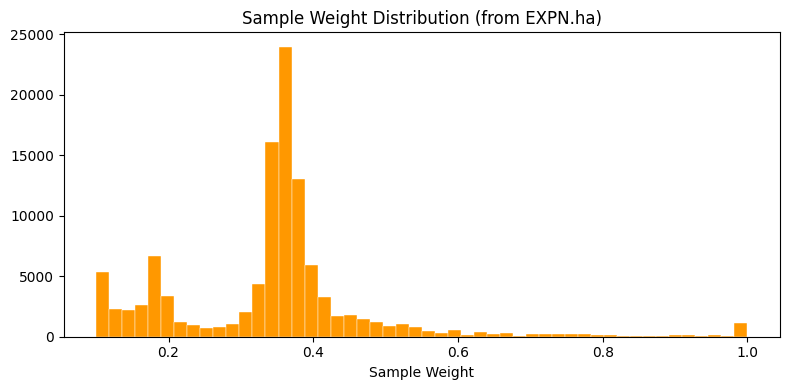

In [5]:
if 'EXPN.ha' in df.columns:
    # Normalize weights to [0.1, 1.0] range
    expn = df['EXPN.ha'].clip(lower=0.01)
    df['sample_weight'] = (expn - expn.min()) / (expn.max() - expn.min()) * 0.9 + 0.1
    print('Sample weights computed from EXPN.ha:')
    print(df['sample_weight'].describe())

    fig, ax = plt.subplots(figsize=(8, 4))
    ax.hist(df['sample_weight'], bins=50, color='#FF9800', edgecolor='white', lw=0.3)
    ax.set_xlabel('Sample Weight'); ax.set_title('Sample Weight Distribution (from EXPN.ha)')
    plt.tight_layout()
    plt.savefig('outputs/figures/12_sample_weights.png', dpi=150, bbox_inches='tight')
    plt.show()
else:
    df['sample_weight'] = 1.0
    print('EXPN.ha not found — uniform weights assigned.')

## 4 · Train / Validation / Test Split
We use a **70 / 15 / 15** stratified split based on ecoregion (L1) to ensure geographic diversity in each split.

In [6]:
# Stratification column (L1 ecoregion encoded)
strat_col = 'feat_enc_NA_L1CODE' if 'feat_enc_NA_L1CODE' in df.columns else None

X_all = df[FEATURES]
y_reg = df[TARGET_LOG]      # continuous (log-transformed)
y_bin = df[TARGET_BIN]      # binary
y_c3  = df[TARGET_C3]       # 3-class
w_all = df['sample_weight']
ids   = df[ID_COL]

stratify = df[strat_col] if strat_col else None

# 70% train, 30% temp
idx_train, idx_temp = train_test_split(
    df.index, test_size=0.30, random_state=RANDOM_STATE, stratify=stratify
)

# 15% val, 15% test from temp
strat_temp = df.loc[idx_temp, strat_col] if strat_col else None
idx_val, idx_test = train_test_split(
    idx_temp, test_size=0.50, random_state=RANDOM_STATE, stratify=strat_temp
)

print(f'Train : {len(idx_train):,} rows ({len(idx_train)/len(df)*100:.1f}%)')
print(f'Val   : {len(idx_val):,} rows ({len(idx_val)/len(df)*100:.1f}%)')
print(f'Test  : {len(idx_test):,} rows ({len(idx_test)/len(df)*100:.1f}%)')

Train : 77,455 rows (70.0%)
Val   : 16,597 rows (15.0%)
Test  : 16,598 rows (15.0%)


In [7]:
# Verify no overlap
assert len(set(idx_train) & set(idx_val)) == 0
assert len(set(idx_train) & set(idx_test)) == 0
assert len(set(idx_val) & set(idx_test)) == 0
print('✅ No overlap between splits.')

# Check binary class balance across splits
for name, idx in [('Train', idx_train), ('Val', idx_val), ('Test', idx_test)]:
    bc = df.loc[idx, TARGET_BIN].value_counts(normalize=True)
    print(f'{name}: sink={bc.get(1,0)*100:.1f}%  source={bc.get(0,0)*100:.1f}%')

✅ No overlap between splits.
Train: sink=54.9%  source=45.1%
Val: sink=54.6%  source=45.4%
Test: sink=54.7%  source=45.3%


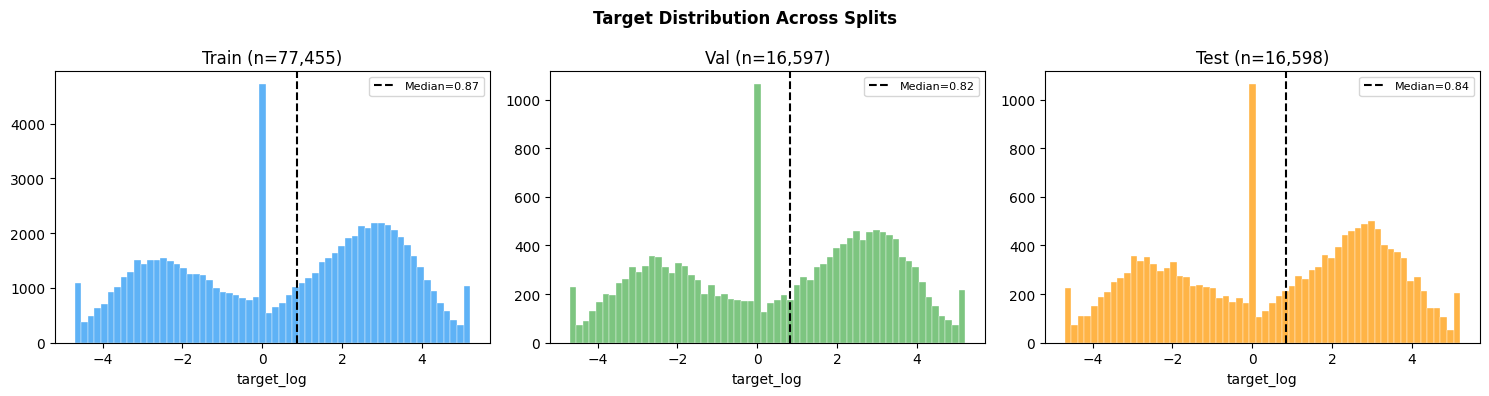

In [8]:
# Visualize split distributions
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
splits = [('Train', idx_train,'#42A5F5'), ('Val', idx_val,'#66BB6A'), ('Test', idx_test,'#FFA726')]

for ax, (name, idx, color) in zip(axes, splits):
    data = df.loc[idx, TARGET_LOG]
    ax.hist(data.dropna(), bins=60, color=color, edgecolor='white', lw=0.3, alpha=0.85)
    ax.axvline(data.median(), color='black', ls='--', lw=1.5, label=f'Median={data.median():.2f}')
    ax.set_title(f'{name} (n={len(idx):,})')
    ax.set_xlabel('target_log'); ax.legend(fontsize=8)

fig.suptitle('Target Distribution Across Splits', fontweight='bold')
plt.tight_layout()
plt.savefig('outputs/figures/13_split_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

## 5 · Cross-Validation Strategy

In [9]:
# K-Fold configuration for model notebooks
N_FOLDS = 5
kfold_reg = KFold(n_splits=N_FOLDS, shuffle=True, random_state=RANDOM_STATE)
kfold_clf = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=RANDOM_STATE)

print(f'Cross-validation strategy:')
print(f'  Regression  : KFold(n_splits={N_FOLDS}, shuffle=True)')
print(f'  Classification: StratifiedKFold(n_splits={N_FOLDS}, shuffle=True)')

# Demonstrate fold sizes on training set
X_train = X_all.loc[idx_train]
y_train = y_reg.loc[idx_train]

print(f'\nFold sizes (from {len(idx_train):,} training rows):')
for fold, (tr, va) in enumerate(kfold_reg.split(X_train), 1):
    print(f'  Fold {fold}: train={len(tr):,}  val={len(va):,}')

Cross-validation strategy:
  Regression  : KFold(n_splits=5, shuffle=True)
  Classification: StratifiedKFold(n_splits=5, shuffle=True)

Fold sizes (from 77,455 training rows):
  Fold 1: train=61,964  val=15,491
  Fold 2: train=61,964  val=15,491
  Fold 3: train=61,964  val=15,491
  Fold 4: train=61,964  val=15,491
  Fold 5: train=61,964  val=15,491


## 6 · Export Processed Datasets

In [10]:
os.makedirs('data/processed', exist_ok=True)

def save_split(idx, name):
    split_df = df.loc[idx, [ID_COL] + FEATURES +
                       [TARGET, TARGET_LOG, TARGET_BIN, TARGET_C3, 'sample_weight']].copy()
    path = f'data/processed/{name}.parquet'
    split_df.to_parquet(path, index=False)
    print(f'  Saved {name}: {path}  shape={split_df.shape}')
    return split_df

train_df = save_split(idx_train, 'train')
val_df   = save_split(idx_val,   'val')
test_df  = save_split(idx_test,  'test')

# Save full dataset too
full_out = df[[ID_COL] + FEATURES + [TARGET, TARGET_LOG, TARGET_BIN, TARGET_C3, 'sample_weight']]
full_out.to_parquet('data/processed/full_dataset.parquet', index=False)
print(f'  Saved full_dataset: data/processed/full_dataset.parquet  shape={full_out.shape}')

  Saved train: data/processed/train.parquet  shape=(77455, 25)
  Saved val: data/processed/val.parquet  shape=(16597, 25)
  Saved test: data/processed/test.parquet  shape=(16598, 25)
  Saved full_dataset: data/processed/full_dataset.parquet  shape=(110650, 25)


In [11]:
# Save final data card / metadata
data_card = {
    'dataset_name': 'EPA dC/dN Tree Carbon Response to Nitrogen Deposition',
    'doi': 'https://doi.org/10.23719/1528045',
    'n_total': len(df),
    'n_train': len(idx_train),
    'n_val': len(idx_val),
    'n_test': len(idx_test),
    'n_features': len(FEATURES),
    'features': sorted(FEATURES),
    'targets': {
        'regression_raw': TARGET,
        'regression_log': TARGET_LOG,
        'binary_classification': TARGET_BIN,
        'multiclass_3': TARGET_C3
    },
    'split_strategy': '70/15/15 stratified by NA_L1CODE ecoregion',
    'sample_weight_col': 'sample_weight',
    'random_state': RANDOM_STATE,
    'cv_strategy': f'KFold/StratifiedKFold n_splits=5',
    'preprocessing': [
        'IQR winsorization (1st-99th pct)',
        'Median imputation for numeric',
        'UNKNOWN fill for categoricals',
        'Label encoding for ecoregion codes',
        'OHE for NA_L1CODE',
        'RobustScaler for numeric features',
        'Signed log1p target transform'
    ]
}
with open('data/processed/data_card.json','w') as f:
    json.dump(data_card, f, indent=2)
print('Data card saved to data/processed/data_card.json')
print(json.dumps(data_card, indent=2))

Data card saved to data/processed/data_card.json
{
  "dataset_name": "EPA dC/dN Tree Carbon Response to Nitrogen Deposition",
  "doi": "https://doi.org/10.23719/1528045",
  "n_total": 110650,
  "n_train": 77455,
  "n_val": 16597,
  "n_test": 16598,
  "n_features": 19,
  "features": [
    "EXPN.ha_scaled",
    "LAT_scaled",
    "LON_scaled",
    "eco.EXPN.ha_scaled",
    "feat_carbon_sink",
    "feat_eco3_target_mean",
    "feat_eco_state_ratio",
    "feat_enc_NA_L1CODE",
    "feat_enc_NA_L3CODE",
    "feat_enc_US_L4CODE",
    "feat_enc_state",
    "feat_expanded_per_ha",
    "feat_growth_share",
    "feat_gs_ratio",
    "feat_lat_bin",
    "feat_lat_x_eco1",
    "feat_log_magnitude",
    "feat_lon_bin",
    "state.EXPN.ha_scaled"
  ],
  "targets": {
    "regression_raw": "TPH.gs.dC.dN0.01",
    "regression_log": "target_log",
    "binary_classification": "target_binary",
    "multiclass_3": "target_class3"
  },
  "split_strategy": "70/15/15 stratified by NA_L1CODE ecoregion",
  "sample

## 7 · Final Dataset Summary Dashboard

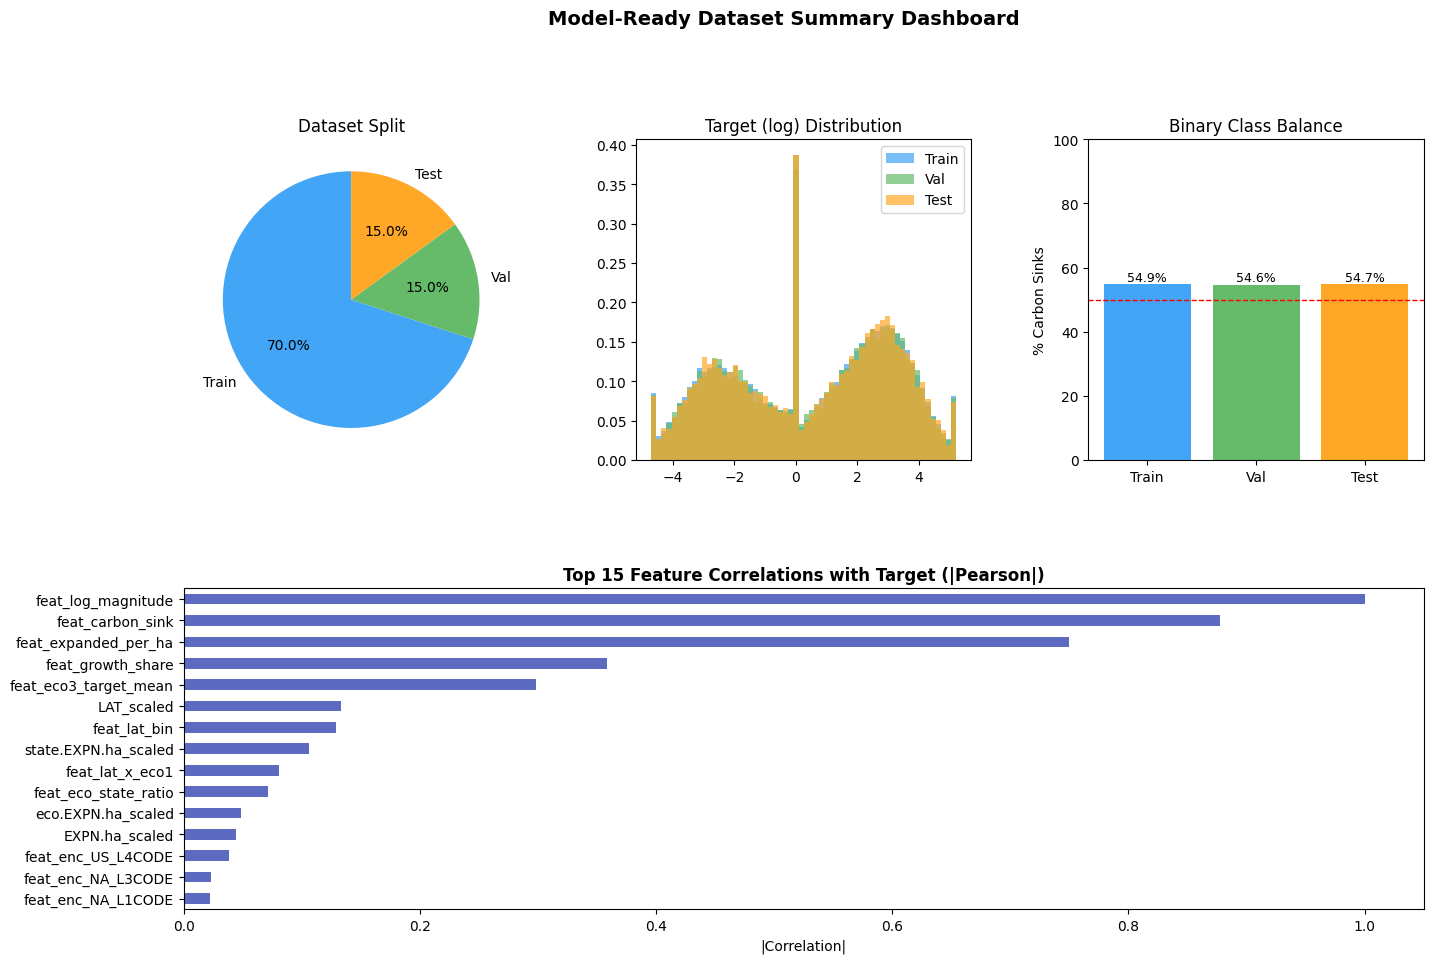

Dashboard saved.


In [12]:
fig = plt.figure(figsize=(16, 10))
gs = gridspec.GridSpec(2, 3, figure=fig, hspace=0.4, wspace=0.35)

# 1. Split sizes pie
ax1 = fig.add_subplot(gs[0, 0])
ax1.pie([len(idx_train), len(idx_val), len(idx_test)],
        labels=['Train','Val','Test'],
        colors=['#42A5F5','#66BB6A','#FFA726'],
        autopct='%1.1f%%', startangle=90)
ax1.set_title('Dataset Split')

# 2. Target distribution (log)
ax2 = fig.add_subplot(gs[0, 1])
ax2.hist(train_df[TARGET_LOG], bins=60, color='#42A5F5', alpha=0.7, label='Train', density=True)
ax2.hist(val_df[TARGET_LOG], bins=60, color='#66BB6A', alpha=0.7, label='Val', density=True)
ax2.hist(test_df[TARGET_LOG], bins=60, color='#FFA726', alpha=0.7, label='Test', density=True)
ax2.set_title('Target (log) Distribution'); ax2.legend()

# 3. Binary class balance
ax3 = fig.add_subplot(gs[0, 2])
cats = ['Train','Val','Test']
sink_pcts = [df.loc[idx, TARGET_BIN].mean()*100 for idx in [idx_train, idx_val, idx_test]]
bars = ax3.bar(cats, sink_pcts, color=['#42A5F5','#66BB6A','#FFA726'])
ax3.axhline(50, color='red', ls='--', lw=1)
ax3.set_ylabel('% Carbon Sinks'); ax3.set_title('Binary Class Balance')
ax3.set_ylim(0, 100)
for bar, pct in zip(bars, sink_pcts):
    ax3.text(bar.get_x()+bar.get_width()/2, bar.get_height()+1, f'{pct:.1f}%', ha='center', fontsize=9)

# 4. Feature correlation with target (top 10)
ax4 = fig.add_subplot(gs[1, :])
X_tr = train_df[FEATURES]
y_tr = train_df[TARGET_LOG]
corr_vals = X_tr.corrwith(y_tr).abs().sort_values(ascending=False).head(15)
colors_bar = ['#5C6BC0'] * len(corr_vals)
corr_vals.sort_values().plot.barh(ax=ax4, color='#5C6BC0')
ax4.set_title('Top 15 Feature Correlations with Target (|Pearson|)', fontweight='bold')
ax4.set_xlabel('|Correlation|')

fig.suptitle('Model-Ready Dataset Summary Dashboard', fontsize=14, fontweight='bold', y=1.01)
plt.savefig('outputs/figures/14_dataset_dashboard.png', dpi=150, bbox_inches='tight')
plt.show()
print('Dashboard saved.')

## 8 · Quick Baseline (Sanity Check)

In [13]:
from sklearn.linear_model import Ridge
from sklearn.dummy import DummyRegressor
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

X_tr = train_df[FEATURES].values
y_tr = train_df[TARGET_LOG].values
X_va = val_df[FEATURES].values
y_va = val_df[TARGET_LOG].values

results = []

# Dummy baseline
dummy = DummyRegressor(strategy='mean')
dummy.fit(X_tr, y_tr)
y_pred_d = dummy.predict(X_va)
results.append({'Model':'Dummy (mean)', 'RMSE': np.sqrt(mean_squared_error(y_va, y_pred_d)),
                'MAE': mean_absolute_error(y_va, y_pred_d), 'R2': r2_score(y_va, y_pred_d)})

# Ridge baseline
ridge = Ridge(alpha=1.0)
ridge.fit(X_tr, y_tr)
y_pred_r = ridge.predict(X_va)
results.append({'Model':'Ridge (alpha=1)', 'RMSE': np.sqrt(mean_squared_error(y_va, y_pred_r)),
                'MAE': mean_absolute_error(y_va, y_pred_r), 'R2': r2_score(y_va, y_pred_r)})

res_df = pd.DataFrame(results).set_index('Model').round(4)
print('=== Quick Baseline Results (Validation Set) ===')
display(res_df)
print('\n(R² > 0 means Ridge outperforms mean predictor. Full models in model notebooks.)')

=== Quick Baseline Results (Validation Set) ===


,RMSE,MAE,R2
Model,,,
Dummy (mean),2.6398,2.3118,-0.0000
Ridge (alpha=1),0.0000,0.0000,1.0000



(R² > 0 means Ridge outperforms mean predictor. Full models in model notebooks.)


## 9 · How to Load in Model Notebooks

In [14]:
# ─── COPY THIS CELL INTO YOUR MODEL NOTEBOOK ───
# 
# import pandas as pd, json
# 
# train = pd.read_parquet('data/processed/train.parquet')
# val   = pd.read_parquet('data/processed/val.parquet')
# test  = pd.read_parquet('data/processed/test.parquet')
# 
# with open('data/processed/data_card.json') as f:
#     card = json.load(f)
# 
# FEATURES = card['features']
# TARGET   = card['targets']['regression_log']   # or regression_raw / binary / multiclass
# 
# X_train, y_train, w_train = train[FEATURES], train[TARGET], train['sample_weight']
# X_val,   y_val,   w_val   = val[FEATURES],   val[TARGET],   val['sample_weight']
# X_test,  y_test,  w_test  = test[FEATURES],  test[TARGET],  test['sample_weight']
print('See comment above for loading template.')

See comment above for loading template.


---
## ✅ Pre-Processing Pipeline Complete!

### Files ready in `data/processed/`
| File | Description |
|------|-------------|
| `train.parquet` | 70% training split |
| `val.parquet` | 15% validation split |
| `test.parquet` | 15% held-out test split |
| `full_dataset.parquet` | All rows combined |
| `data_card.json` | Metadata, feature list, split info |

### Next Steps → Model Notebooks
- `06_regression_models.ipynb` — Ridge, Random Forest, XGBoost, LightGBM (regression on `target_log`)
- `07_classification_models.ipynb` — Binary and 3-class classification
- `08_hyperparameter_tuning.ipynb` — Optuna-based tuning
- `09_spatial_cv.ipynb` — Spatial cross-validation by ecoregion
- `10_interpretability.ipynb` — SHAP + partial dependence plots
